In [2]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_plots import NeuronPlots
from neuron_utils import NeuronUtils
from neuron import h
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LTP → Poisson inputs (in electric field)

In the previous simulation, we performed LTP induction protocol and obtained synaptic weights. Here they are:

In [3]:
synapse_info = pd.read_csv("final_ef.csv", index_col = 0)
synapse_info

,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,14,0.139538,116.315870,500,0.0001,0.584171
1,6,0.676699,119.467511,500,0.0001,0.226987
2,27,0.031783,214.478018,500,0.0001,0.219802
3,5,0.218638,125.874136,500,0.0001,0.224814
4,26,0.220441,237.214368,500,0.0001,0.212656
5,37,0.278191,286.953628,500,0.0001,0.215314
6,21,0.277871,179.285582,500,0.0001,0.231749
7,13,0.957213,199.340123,500,0.0001,0.659780
8,21,0.102210,153.333687,500,0.0001,0.239147
9,24,0.096716,191.699553,500,0.0001,0.224504


Now, we will recreate the neuron with these synaptic weights.

The synapses will be stimulated with unsynchronized Poisson inputs in the theta range (5 Hz).

In [4]:
# Parameters
rate = 5  # Hz
duration = 30 * 1000  # ms # TODO: change to a minute

In [5]:
def generate_poisson_spike_times(rate, duration):
    """Generate Poisson-distributed spike times."""
    spikes = []
    t = np.random.exponential(1000 / rate)
    spikes.append(t)
    
    while t < duration:
        spikes.append(t)
        isi = np.random.exponential(1000 / rate)  # Exponential ISI
        t += isi
    
    return spikes

In [6]:
# Generate a list of random seeds to use when generating stimuli
np.random.seed(132)
seeds = np.random.choice(range(10000), 10, replace=False)

seed_counter = -1

# Define the stimulus
def poisson_stimulus():
    global seed_counter
    seed_counter += 1
    
    np.random.seed(seeds[seed_counter])
    
    # Generate spike times
    spike_times = generate_poisson_spike_times(rate, duration)

    spike_vec = h.Vector(spike_times)
    stimulus = h.VecStim()
    stimulus.play(spike_vec)
    
    return stimulus

In [7]:
# Resetting the delay
synapse_info.Delay = 0

In [8]:
neuron = PlasticNeuron(
    synapse_info = synapse_info,
    generate_stimulus = poisson_stimulus
)

neuron.synapse_info

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Reading synapse information
Inserting 10 synapses


,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,14,0.139538,116.315870,0,0.0001,0.584171
1,6,0.676699,119.467511,0,0.0001,0.226987
2,27,0.031783,214.478018,0,0.0001,0.219802
3,5,0.218638,125.874136,0,0.0001,0.224814
4,26,0.220441,237.214368,0,0.0001,0.212656
5,37,0.278191,286.953628,0,0.0001,0.215314
6,21,0.277871,179.285582,0,0.0001,0.231749
7,13,0.957213,199.340123,0,0.0001,0.659780
8,21,0.102210,153.333687,0,0.0001,0.239147
9,24,0.096716,191.699553,0,0.0001,0.224504


We run the simulation for 60 seconds.

In [9]:
NeuronUtils.set_stimulus(
    duration = duration,
    frequency1 = 1000,
    frequency2 = 1005,
    phase = 10,
    amplitude = 134,
    delay = 0
)
neuron.run(duration)

Neuron initialized
Elapsed time: 715.79 seconds


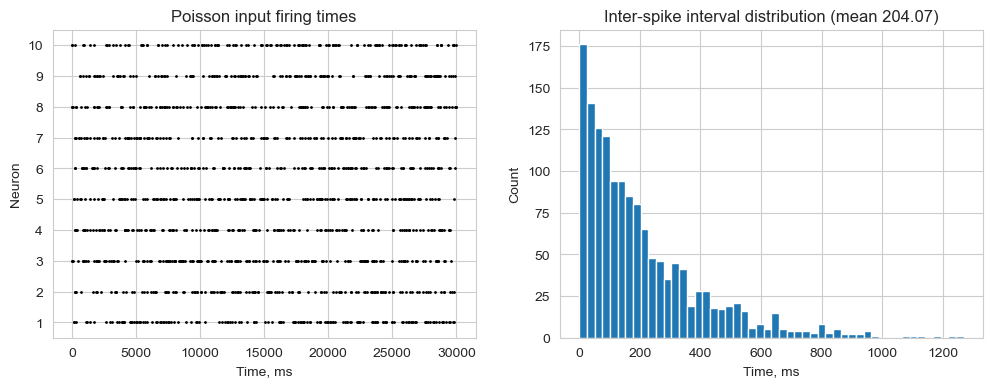

In [10]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))

for i, synapse in enumerate(neuron.synapses):
    time = synapse.stimuli
    axs[0].scatter(time, np.repeat(i + 1, repeats = len(time)), color = "black", s = 1)

axs[0].set_ylim(0.5, 10.5)
axs[0].set_ylabel("Neuron")
axs[0].set_yticks(np.arange(1, 11, 1))
axs[0].set_xlabel("Time, ms")
axs[0].set_title("Poisson input firing times")

freqs = []
for synapse in neuron.synapses:
    freqs.append(np.diff(synapse.stimuli)[1:])
freqs = np.concatenate(freqs)

axs[1].hist(freqs, bins = 50)
axs[1].set_xlabel("Time, ms")
axs[1].set_ylabel("Count")
axs[1].set_title(f"Inter-spike interval distribution (mean {round(np.mean(freqs), 2)})")

plt.show()

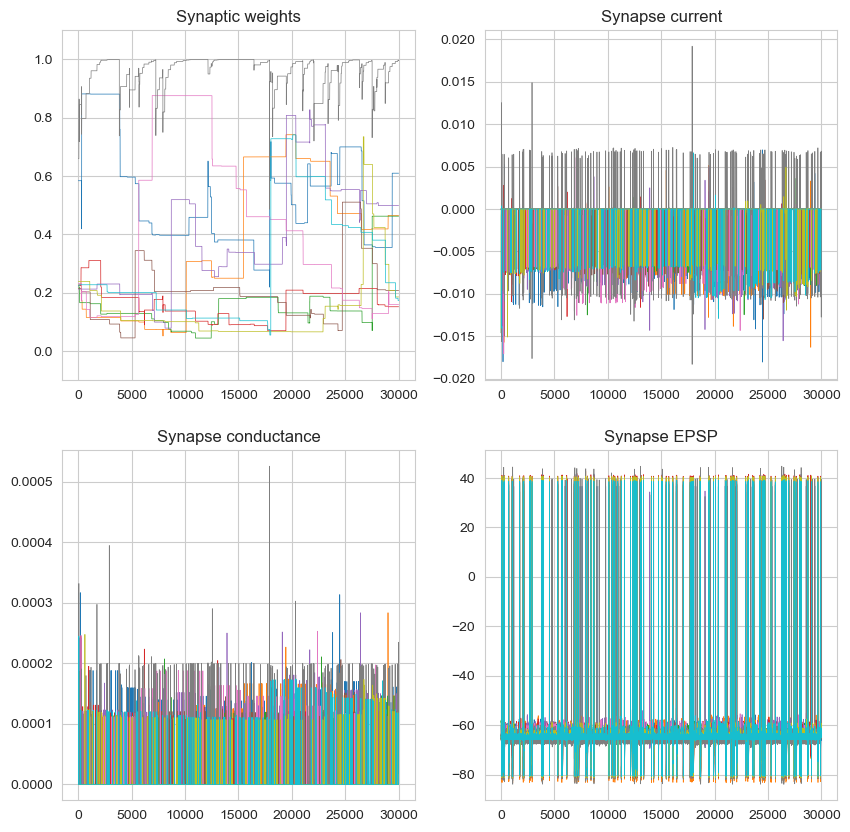

In [11]:
NeuronPlots.plot_all_synapses(neuron)

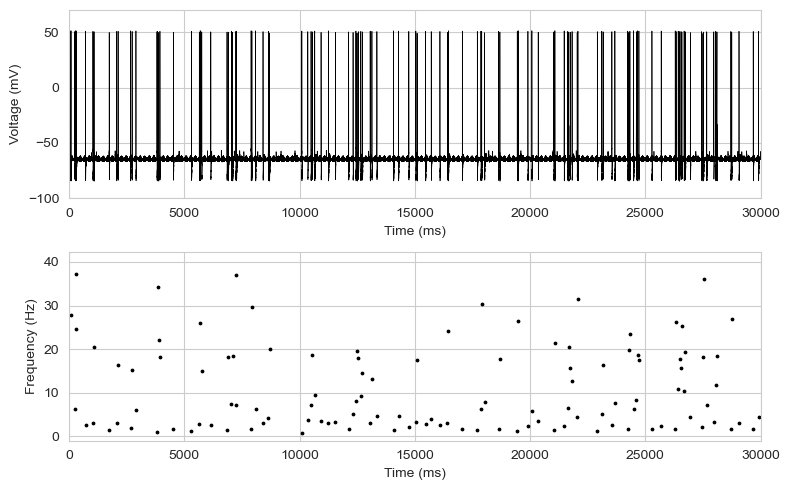

In [12]:
NeuronPlots.plot_spike_frequency(neuron)